# Airbnb NYC Data Analysis

## Project Overview
This project analyzesAirbnb listings in New York City using Python libraries such as Pandas, Matplotlib and Seaborn. The goal is to identify pricing trends, listing distributions, customer behavior and geographical patterns through exploratory data analysis (EDA).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("AB_NYC_2019.csv")

## Preview of Dataset

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [6]:
df.shape

(48895, 16)

In [7]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [10]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['room_type'].unique()

<ArrowStringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

In [13]:
df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

## Data Cleaning

In [14]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [15]:
df = df.dropna()

In [16]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [18]:
df.shape

(38821, 16)

## Handling Missing Values and Duplicates

In [19]:
df = df.drop_duplicates()

In [20]:
df.duplicated().sum()

np.int64(0)

In [22]:
df['price'].mean()

np.float64(142.33252621004095)

In [23]:
df['price'].max()

np.int64(10000)

In [24]:
df['price'].min()

np.int64(0)

In [25]:
df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        16621
Brooklyn         16439
Queens            4572
Bronx              875
Staten Island      314
Name: count, dtype: int64

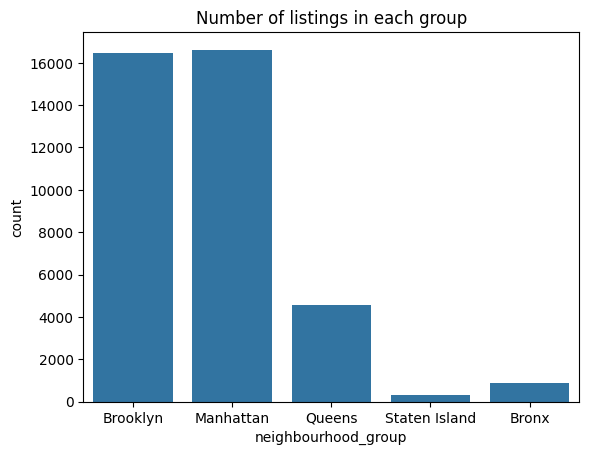

In [26]:
sns.countplot(x='neighbourhood_group', data=df)
plt.title("Number of listings in each group")
plt.show()

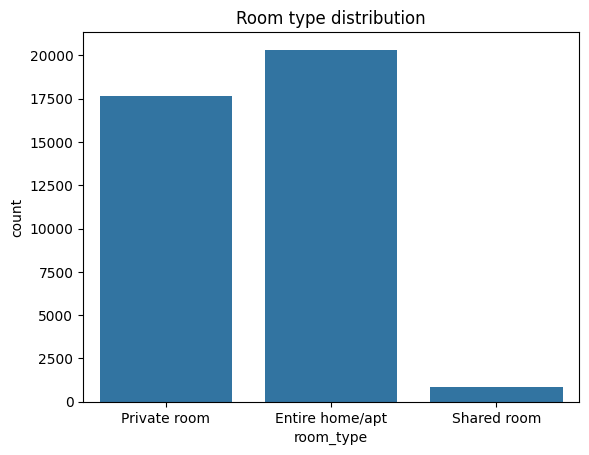

In [27]:
sns.countplot( x='room_type', data=df)
plt.title("Room type distribution")
plt.show()

## Exploratory Data Analysis

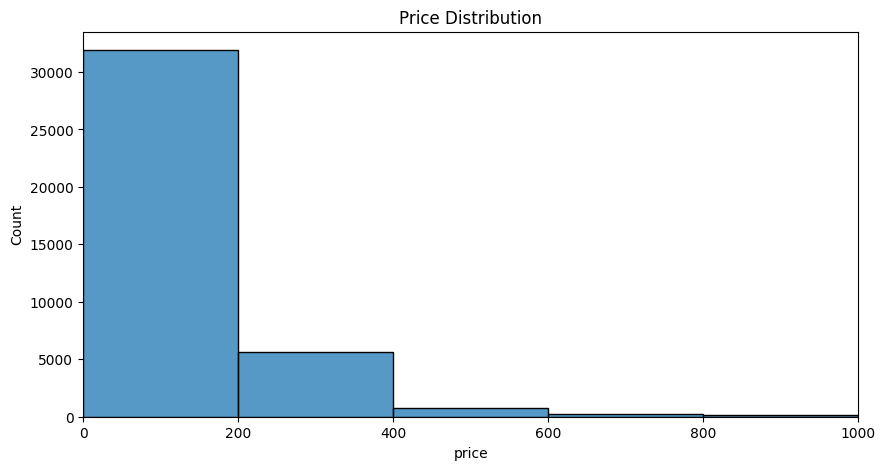

In [28]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50)
plt.xlim(0,1000)
plt.title("Price Distribution")
plt.show()

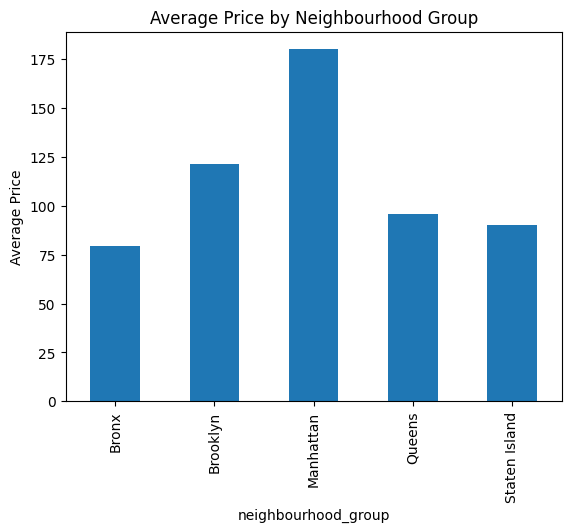

In [32]:
avg_price = df.groupby('neighbourhood_group')['price'].mean()

avg_price.plot(kind='bar')
plt.title("Average Price by Neighbourhood Group")
plt.ylabel("Average Price")
plt.show()

In [33]:
top_neighbourhoods = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)
top_neighbourhoods.head(10)

neighbourhood
Sea Gate             482.500000
Tribeca              460.300000
NoHo                 298.451613
Flatiron District    291.482759
SoHo                 281.303136
Neponsit             274.666667
Midtown              267.583164
West Village         250.326230
Willowbrook          249.000000
Greenwich Village    239.120915
Name: price, dtype: float64

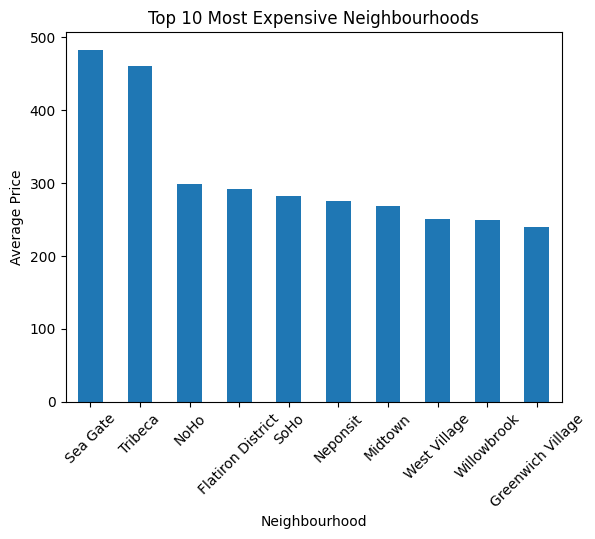

In [34]:
top_neighbourhoods.head(10).plot(kind='bar')

plt.title("Top 10 Most Expensive Neighbourhoods")
plt.ylabel("Average Price")
plt.xlabel("Neighbourhood")

plt.xticks(rotation=45)

plt.show()

In [35]:
df['room_type'].value_counts()

room_type
Entire home/apt    20321
Private room       17654
Shared room          846
Name: count, dtype: int64

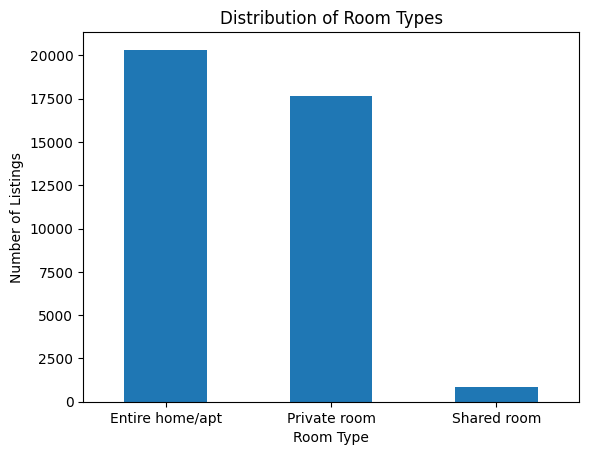

In [36]:
df['room_type'].value_counts().plot(kind='bar')

plt.title("Distribution of Room Types")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

plt.xticks(rotation=0)

plt.show()

In [37]:
room_price = df.groupby('room_type')['price'].mean()

room_price

room_type
Entire home/apt    196.315929
Private room        83.985272
Shared room         63.213948
Name: price, dtype: float64

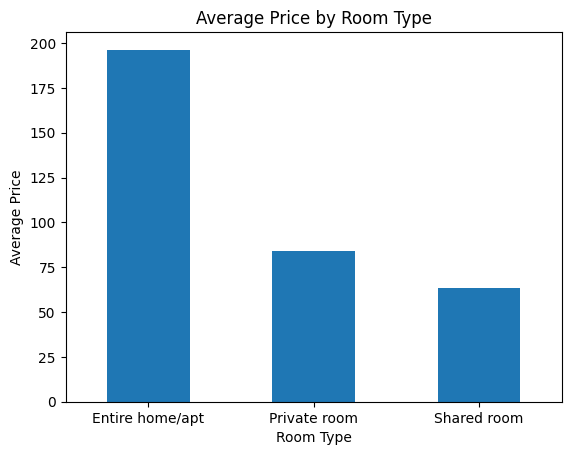

In [38]:
room_price.plot(kind='bar')

plt.title('Average Price by Room Type')
plt.xlabel("Room Type")
plt.ylabel('Average Price')

plt.xticks(rotation=0)

plt.show()

In [39]:
df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

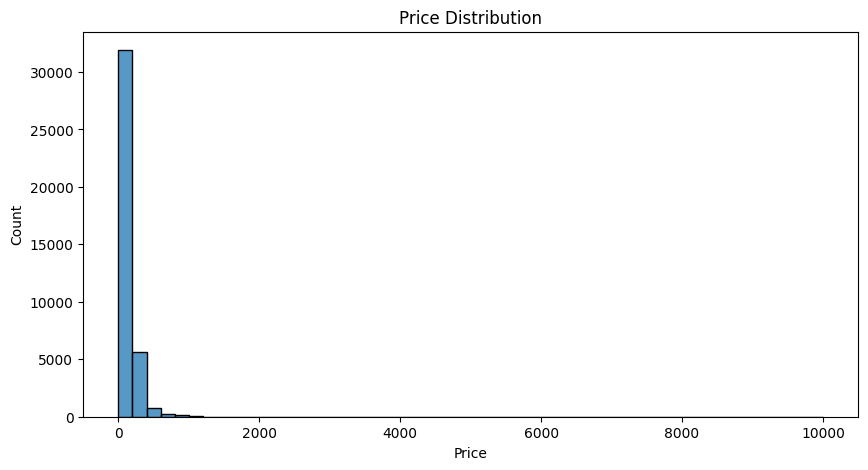

In [40]:
plt.figure(figsize=(10,5))

sns.histplot(df['price'], bins=50)

plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')

plt.show()

In [41]:
df['price'].max()

np.int64(10000)

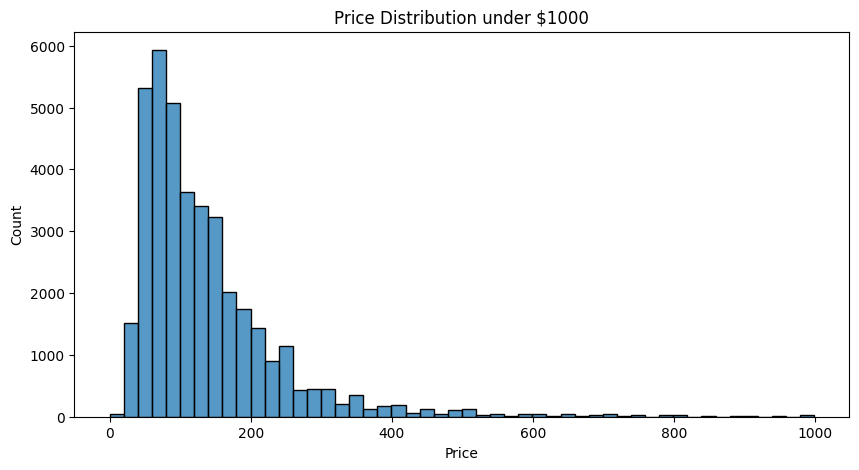

In [42]:
plt.figure(figsize=(10,5))

sns.histplot(df[df['price']<1000]['price'], bins=50)

plt.title("Price Distribution under $1000")
plt.xlabel('Price')
plt.ylabel('Count')

plt.show()

## Borough-wise Price Analysis

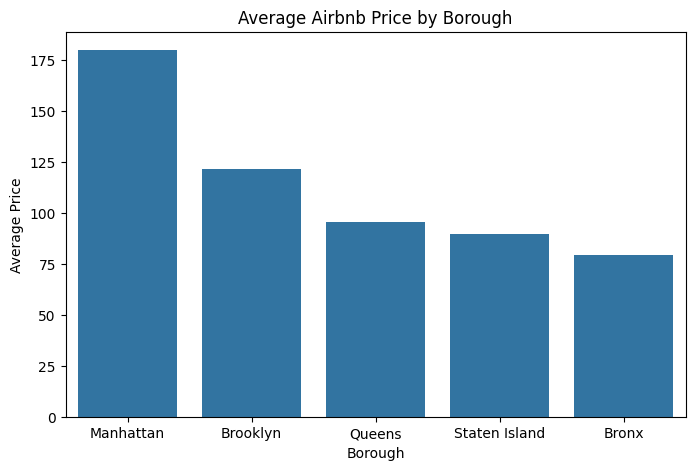

In [44]:
borough_price = df.groupby("neighbourhood_group")['price'].mean().sort_values(ascending= False)

plt.figure(figsize=(8,5))

sns.barplot(x=borough_price.index, y=borough_price.values)

plt.title("Average Airbnb Price by Borough")
plt.xlabel("Borough")
plt.ylabel("Average Price")

plt.show()

In [45]:
borough_count = df['neighbourhood_group'].value_counts()

borough_count

neighbourhood_group
Manhattan        16621
Brooklyn         16439
Queens            4572
Bronx              875
Staten Island      314
Name: count, dtype: int64

## Listing Distribution Across Boroughs

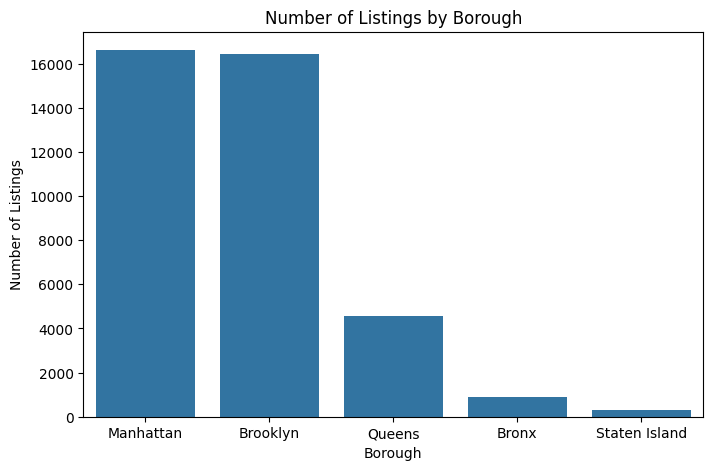

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(x=borough_count.index, y=borough_count.values)

plt.title("Number of Listings by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Listings")

plt.show()

## Customer Engagement Analysis

In [47]:
top_reviews = df.sort_values(by='number_of_reviews', ascending=False)

top_reviews[['name', 'neighbourhood_group', 'room_type', 'number_of_reviews']].head(10)

,name,neighbourhood_group,room_type,number_of_reviews
11759,Room near JFK Queen Bed,Queens,Private room,629
2031,Great Bedroom in Manhattan,Manhattan,Private room,607
2030,Beautiful Bedroom in Manhattan,Manhattan,Private room,597
2015,Private Bedroom in Manhattan,Manhattan,Private room,594
13495,Room Near JFK Twin Beds,Queens,Private room,576
10623,Steps away from Laguardia airport,Queens,Private room,543
1879,Manhattan Lux Loft.Like.Love.Lots.Look !,Manhattan,Private room,540
20403,Cozy Room Family Home LGA Airport NO CLEANING FEE,Queens,Private room,510
4870,Private brownstone studio Brooklyn,Brooklyn,Entire home/apt,488
471,LG Private Room/Family Friendly,Brooklyn,Private room,480


## Host Activity Analysis

In [48]:
top_hosts= df['host_name'].value_counts().head(10)

top_hosts

host_name
Michael         335
David           309
John            250
Alex            229
Sonder (NYC)    207
Sarah           179
Maria           174
Daniel          170
Jessica         170
Anna            159
Name: count, dtype: int64

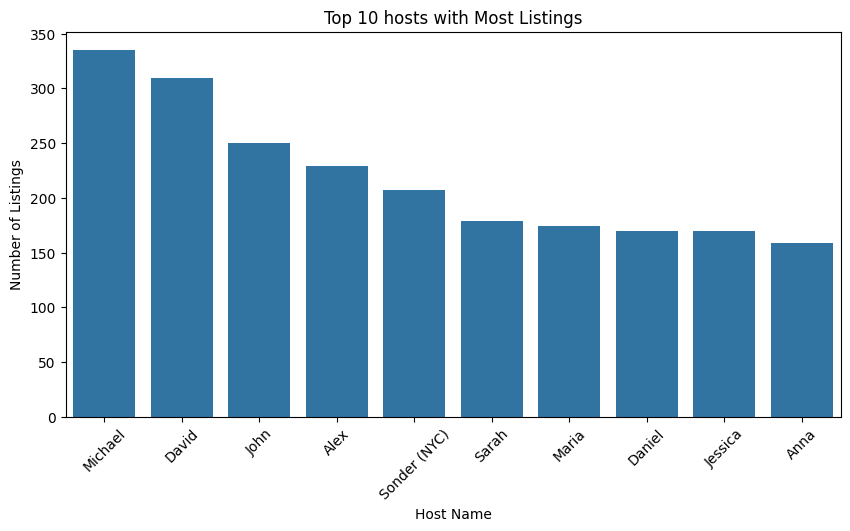

In [49]:
plt.figure(figsize=(10,5))

sns.barplot(x= top_hosts.index, y= top_hosts.values)

plt.title("Top 10 hosts with Most Listings")
plt.xlabel("Host Name")
plt.ylabel("Number of Listings")

plt.xticks(rotation=45)

plt.show()

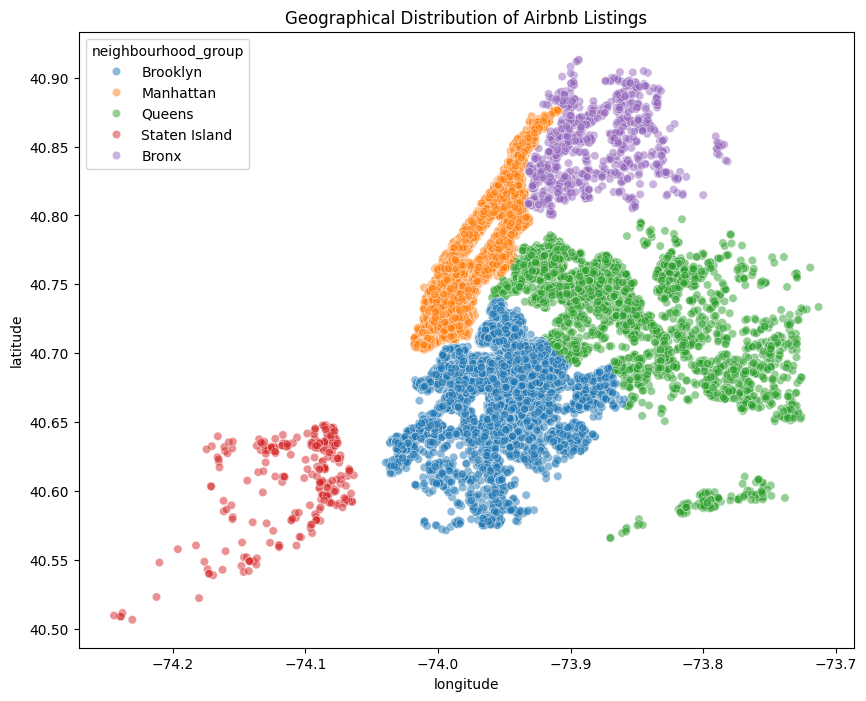

In [51]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x=df['longitude'],
    y=df['latitude'],
    hue=df['neighbourhood_group'],
    alpha=0.5
)

plt.title('Geographical Distribution of Airbnb Listings')

plt.show()

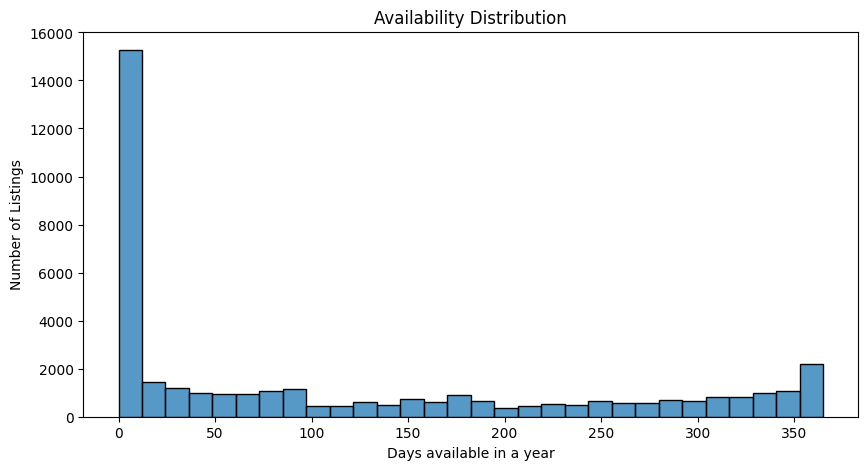

In [52]:
plt.figure(figsize=(10,5))

sns.histplot(df['availability_365'], bins=30)

plt.title("Availability Distribution")
plt.xlabel("Days available in a year")
plt.ylabel("Number of Listings")

plt.show()

In [53]:
availability = df.groupby('neighbourhood_group')['availability_365'].mean()

availability

neighbourhood_group
Bronx            171.106286
Brooklyn         105.847862
Manhattan        109.340112
Queens           150.554899
Staten Island    205.640127
Name: availability_365, dtype: float64

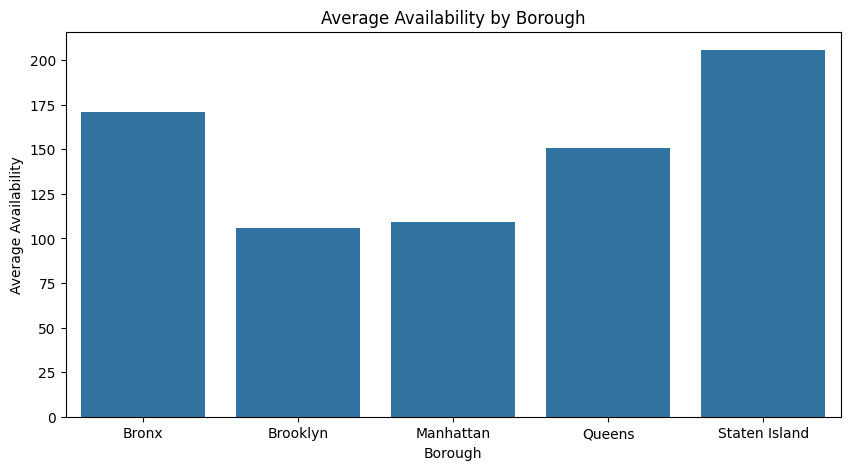

In [54]:
plt.figure(figsize=(10,5))

sns.barplot(x=availability.index, y=availability.values)

plt.title("Average Availability by Borough")
plt.xlabel("Borough")
plt.ylabel("Average Availability")

plt.show()

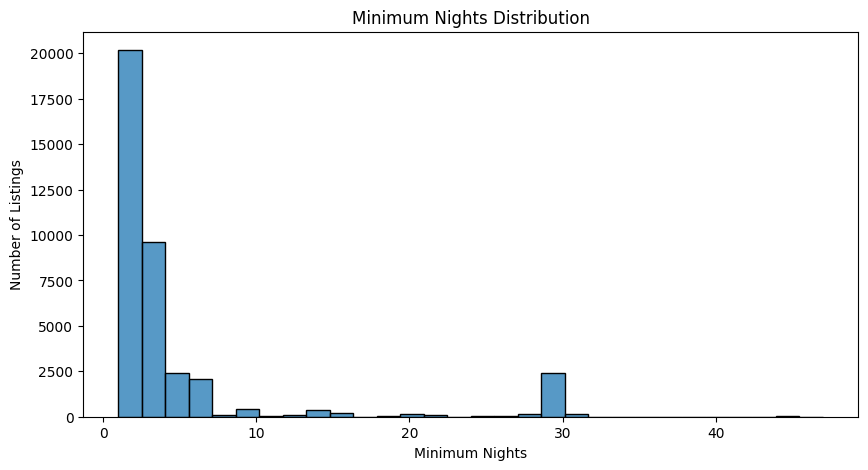

In [55]:
plt.figure(figsize=(10,5))
sns.histplot(df[df['minimum_nights']<50]['minimum_nights'],bins=30)

plt.title("Minimum Nights Distribution")
plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings")

plt.show()

In [56]:
min_nights=df.groupby('neighbourhood_group')['minimum_nights'].mean()
min_nights

neighbourhood_group
Bronx            3.932571
Brooklyn         5.320153
Manhattan        7.013477
Queens           4.222441
Staten Island    3.420382
Name: minimum_nights, dtype: float64

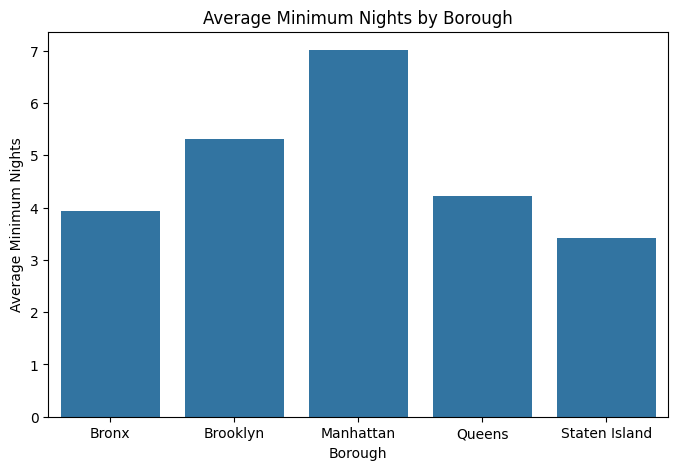

In [58]:
plt.figure(figsize=(8,5))

sns.barplot(x=min_nights.index, y=min_nights.values)

plt.title("Average Minimum Nights by Borough")
plt.xlabel("Borough")
plt.ylabel("Average Minimum Nights")

plt.show()

## Key Findings


- most airbnb listings are concentrated with lower and moderate price range, while a few extreme outliers significantly affect the overall price distribution.
- Manhattan has the highest average Airbnb prices, indicating strong demand and premium property value in central urban areas.
- Manhattan and Brooklyn contains the largest number of Airbnb listings, showing that Airbnb activity is highly concentrated in these boroughs.
- Entire home/apartment is the most common expensive room type, while private rooms are generally more affordable.
- Several hosts manage multiple listings, indicating the presence of professional hosting business on the Airbnb platform.
- Geographical analysis shows dense clustering of Airbnb listings in Manhattan and Brooklyn regions.
- Most properties require short minimum stays, suggesting that Airbnb is primarily used for short-term accomodation.
- Availability patterns vary across boroughs, reflecting differences in customer demand and hosting strategies.

## Final Conclusion

This project analyzed airbnb listings in New York City using Python-based exploratory data analysis techniques.The analysis revealed important insights related to pricing, room types, listing distribution, availability and customer engagement across different boroughs. Through data cleaning, visualization and trend analysis, the project demonstrated how real-world datasets can be transformed into meaningful business insights using data analytics tool.